# Merinos Halı Sanayi A.Ş. — Day 26
## Vektör Veritabanı Optimizasyonu & İndeksleme (Vector Database Optimization: HNSW vs IVF, Scalar/Product Quantization & Payload Filtering)

**Müfredat:** 40 Günlük Endüstriyel Yapay Zeka Staj Portföyü  
**Aşama:** Faz 4: Retrieval & Hibrit Arama (Day 22–28)  
**Tesis:** Gaziantep 4. OSB Halı Dokuma & İplik Üretim Tesisleri  
**Yazar:** Seydi Eryılmaz (@seydivakkas)  
**Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Tüm Hakları Saklıdır.

---

### Çalışmanın Amacı ve Endüstriyel Motivasyon
Merinos Gaziantep fabrikalarındaki yüz binlerce dokuma SOP dokümanı, sensör loğu ve bakım arıza kaydında milisaniye-altı latans (sub-millisecond latency) ile anlamsal getirme yapabilmek için saf kaba kuvvet (Exact Flat) vektör taraması yetersiz kalmaktadır. Milyonlarca yüksek boyutlu (384-D veya 768-D) gömmenin RAM üzerinde tutulması hem donanım maliyetini katlamakta hem de arama gecikmesini artırmaktadır.

Bu çalışmada şu modern vektör arama optimizasyonları incelenmiş ve kurumsal veri setimiz üzerinde kıyaslanmıştır:
1. **Ters Çevrilmiş Dosya İndeksi (Inverted File Index - IVF):** $k$-Means Voronoi hücreleri ve $nprobe$ yönlendirmesi.
2. **Hiyerarşik Gezinilebilir Küçük Dünya Grafiği (HNSW):** Çok katmanlı atlama grafiği ve yerel en yakın komşu arama.
3. **Kuantizasyon Stratejileri:** Skaler Kuantizasyon (SQ8 Int8 ile %64 bellek tasarrufu) ve Ürün Kuantizasyonu (Product Quantization - PQ).
4. **Yük (Payload) Filtreleme:** Ön-filtreleme (Pre-filtering) vs Son-filtreleme (Post-filtering) mekanizmaları ve Qdrant entegrasyonu.

### Adım 1: Ortam Kurulumu ve Gerekli Kütüphanelerin Yüklenmesi

In [1]:
%matplotlib inline
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith('day') else CURRENT_DIR
repo_root = PROJECT_ROOT
DAY26_DIR = PROJECT_ROOT / 'day26'
DAY_DIR = DAY26_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day26.mini_project.src.models import VectorPoint, PayloadFilter, FilterCondition
from day26.mini_project.src.quantization import ScalarQuantizer, ProductQuantizer
from day26.mini_project.src.ivf_index import InvertedFileIndex
from day26.mini_project.src.hnsw_index import HNSWVectorIndex
from day26.mini_project.src.qdrant_manager import QdrantVectorStore
from day26.mini_project.src.benchmarker import VectorIndexBenchmarker
from day26.mini_project.src.visualizer import plot_vector_index_diagnostic_panel

print('✅ Gerekli modüller ve Day 26 optimizasyon bileşenleri başarıyla yüklendi.')

✅ Gerekli modüller ve Day 26 optimizasyon bileşenleri başarıyla yüklendi.


### Adım 2: Vektör Korpusu ve Filtreli Sorguların Yüklenmesi
Merinos dokuma tezgâhları, iplik büküm üniteleri ve kalite kontrol birimlerine ait 66 teknik vektör noktası (384 boyutlu dense embeddings) ve 15 adet filtrelenmiş arıza sorgusu yüklenir.

In [2]:
corpus_path = repo_root / "day26" / "mini_project" / "fixtures" / "merinos_vector_corpus.json"
queries_path = repo_root / "day26" / "mini_project" / "fixtures" / "filtered_benchmark_queries.json"

with open(corpus_path, "r", encoding="utf-8") as f:
    corpus_raw = json.load(f)
corpus_points = [VectorPoint(**p) for p in corpus_raw]

with open(queries_path, "r", encoding="utf-8") as f:
    queries_raw = json.load(f)

print(f"📊 Yüklenen Vektör Noktası Sayısı: {len(corpus_points)}")
print(f"📊 Vektör Boyutu: {len(corpus_points[0].vector)}")
print(f"📊 Kıyaslama Sorgusu Sayısı: {len(queries_raw)}")
print(f"Örnek Vektör Payload'ı: {corpus_points[0].payload}")

📊 Yüklenen Vektör Noktası Sayısı: 66
📊 Vektör Boyutu: 384
📊 Kıyaslama Sorgusu Sayısı: 15
Örnek Vektör Payload'ı: {'chunk_id': 'SOP-001_chunk_001', 'doc_id': 'SOP-001', 'title': 'Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü', 'breadcrumbs': 'Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü > Van de Wiele RCE02 Jakarlı Halı Dokuma Tezgâhı Kapsamlı Bakım ve Çözgü Gerilim Protokolü', 'machine': 'Van de Wiele RCE02', 'department': 'DOKUMA_TEZGAHI_BAKIM', 'component': 'Çözgü Fren & Dişli', 'priority': 'CRITICAL', 'char_length': 90, 'token_count': 15}


### Adım 3: Skaler Kuantizasyon (Scalar Quantization - SQ8) ve Hata Analizi
Float32 değerler (4 bayt) Int8 değerlere (1 bayt) dönüştürülerek %75 teorik bellek tasarrufu hedeflenir. Rekonstrüksiyon ortalama kare hatası (MSE) hesaplanır.

In [3]:
vectors = np.array([p.vector for p in corpus_points], dtype=np.float32)
sq = ScalarQuantizer()
sq.fit(vectors)

q_vecs, scales, offsets = sq.quantize(vectors)
rec_vecs = sq.dequantize(q_vecs, scales, offsets)
mse = float(np.mean((vectors - rec_vecs) ** 2))

print(f"✅ Skaler Kuantizasyon Tamamlandı.")
print(f"Orijinal Boyut (float32): {vectors.nbytes} bayt")
print(f"Kuantize Boyut (int8): {q_vecs.nbytes} bayt")
print(f"Tasarruf Oranı: %{(1 - q_vecs.nbytes / vectors.nbytes) * 100:.1f}")
print(f"Ortalama Rekonstrüksiyon Hatası (MSE): {mse:.6f}")

✅ Skaler Kuantizasyon Tamamlandı.
Orijinal Boyut (float32): 101376 bayt
Kuantize Boyut (int8): 25344 bayt
Tasarruf Oranı: %75.0
Ortalama Rekonstrüksiyon Hatası (MSE): 0.000000


### Adım 4: Ürün Kuantizasyonu (Product Quantization - PQ) ve Alt Uzay Kod Defterleri
Vektör $m=4$ alt uzaya bölünür ve her alt uzay için $k=8$ küme merkezi ($k^*$) eğitilerek kod defteri (codebook) çıkarılır.

In [4]:
pq = ProductQuantizer(n_subspaces=4, n_clusters=8, random_state=42)
pq.fit(vectors)
pq_codes = pq.encode(vectors)

print(f"✅ Ürün Kuantizasyonu Eğitildi.")
print(f"Alt Uzay Sayısı: {pq.n_subspaces} (Her alt uzay: {pq.sub_dim} boyut)")
print(f"Kod Defteri Boyutu: {pq.codebooks.shape}")
print(f"Örnek PQ Kodları (vektör başına 4 bayt): {pq_codes[0]}")

✅ Ürün Kuantizasyonu Eğitildi.
Alt Uzay Sayısı: 4 (Her alt uzay: 96 boyut)
Kod Defteri Boyutu: (4, 8, 96)
Örnek PQ Kodları (vektör başına 4 bayt): [4 4 5 5]


### Adım 5: Inverted File Index (IVF) Mimarisi ve Voronoi Kümeleme
Vektör uzayı $k$-Means ile $nlist=8$ Voronoi hücresine bölünür. Arama anında $nprobe=3$ merkez seçilerek hücre sınırları taranır.

In [5]:
ivf = InvertedFileIndex(nlist=8, nprobe=3, random_state=42)
ivf.build(corpus_points)

q_vec = np.array(queries_raw[0]["query_vector"], dtype=np.float32)
ivf_results = ivf.search(q_vec, top_k=5)

print(f"✅ IVF İndeksi İnşa Edildi (Hücre sayısı: {ivf.nlist}, nprobe: {ivf.nprobe})")
print(f"Sorgu 1 için IVF İlk 3 Sonuç:")
for r in ivf_results[:3]:
    print(f"  - DocID: {r.doc_id}, Skor: {r.score:.4f}, Başlık: {r.payload.get('breadcrumb', 'N/A')}")

[IVF] Training k-means with 8 ce...
✅ IVF İndeksi İnşa Edildi (Hücre sayısı: 8, nprobe: 3)
Sorgu 1 için IVF İlk 3 Sonuç:
  - DocID: SOP-010, Skor: 0.6486, Başlık: N/A
  - DocID: SOP-010, Skor: 0.6186, Başlık: N/A
  - DocID: SOP-009, Skor: 0.6169, Başlık: N/A


### Adım 6: HNSW (Hierarchical Navigable Small World) Graf İndeksi
Çok katmanlı atlama grafiği ($M=16, efConstruction=64, efSearch=32$) kurularak $\mathcal{O}(\log N)$ arama karmaşıklığı elde edilir.

In [6]:
hnsw = HNSWVectorIndex(M=16, ef_construction=64, ef_search=32, quantize=False)
hnsw.build(corpus_points)

hnsw_results = hnsw.search(q_vec, top_k=5)
print(f"✅ HNSW İndeksi İnşa Edildi (Katman sayısı: {hnsw.max_layer + 1})")
print(f"Sorgu 1 için HNSW İlk 3 Sonuç:")
for r in hnsw_results[:3]:
    print(f"  - DocID: {r.doc_id}, Skor: {r.score:.4f}, Başlık: {r.payload.get('breadcrumb', 'N/A')}")

[HNSW] Building index with m=16, ef_construction=64...
✅ HNSW İndeksi İnşa Edildi (Katman sayısı: 2)
Sorgu 1 için HNSW İlk 3 Sonuç:
  - DocID: SOP-010, Skor: 0.6486, Başlık: N/A
  - DocID: SOP-005, Skor: 0.6327, Başlık: N/A
  - DocID: SOP-010, Skor: 0.6186, Başlık: N/A


### Adım 7: Qdrant Bellek İçi Vektör Veritabanı ve Int8 Kuantizasyon Entegrasyonu
Endüstriyel sınıf Qdrant vektör motoru bellek içinde (`:memory:`) yapılandırılır, HNSW graf indeksleme ve Scalar Quantization (INT8) aktif edilir.

In [7]:
qdrant = QdrantVectorStore(collection_name="merinos_maintenance_v1", vector_size=384, in_memory=True)
qdrant.create_collection(m=16, ef_construct=64, enable_quantization=True)
qdrant.upsert_points(corpus_points)

qdrant_results = qdrant.search(q_vec, top_k=5)
print(f"✅ Qdrant İstemcisi Başlatıldı ve Vektörler İndekslendi.")
print(f"Koleksiyon Durumu: {qdrant.get_collection_info()}")
print(f"Qdrant İlk 3 Sonuç:")
for r in qdrant_results[:3]:
    print(f"  - DocID: {r.doc_id}, Skor: {r.score:.4f}, Makine: {r.payload.get('machine', 'N/A')}")

✅ Qdrant İstemcisi Başlatıldı ve Vektörler İndekslendi.
Koleksiyon Durumu: status=<CollectionStatus.GREEN: 'green'> optimizer_status=<OptimizersStatusOneOf.OK: 'ok'> warnings=None indexed_vectors_count=0 points_count=66 segments_count=1 config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=384, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, memory=None, datatype=None, multivector_config=None), shard_number=None, sharding_method=None, replication_factor=None, write_consistency_factor=None, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=None, payload=None, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=None, memory=None, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, in

### Adım 8: Yük (Payload) Filtreleme: Ön-Filtreleme (Pre-Filtering) Analizi
Sorgu `department == 'dokuma_salonu_1'` filtresi ile yürütülür. Ön-filtreleme sayesinde arama uzayı kısıtlanarak yalnızca geçerli teknik dokümanlar taranır.

In [8]:
filt = PayloadFilter(conditions=[
    FilterCondition(field="department", operator="eq", value="dokuma_salonu_1")
])

filtered_results = qdrant.search(q_vec, payload_filter=filt, top_k=5)
print(f"✅ Ön-Filtreli Arama Tamamlandı (Filtre: department = dokuma_salonu_1):")
for r in filtered_results:
    print(f"  - DocID: {r.doc_id}, Skor: {r.score:.4f}, Dept: {r.payload.get('department')}, Makine: {r.payload.get('machine')}")

✅ Ön-Filtreli Arama Tamamlandı (Filtre: department = dokuma_salonu_1):


### Adım 9: Kapsamlı QPS, Latans, Bellek ve Recall@5 Kıyaslaması
Tüm indeks tipleri (Exact Flat, IVF, HNSW, Quantized HNSW) 15 teknik arıza sorgusu üzerinde karşılaştırılır.

In [9]:
benchmarker = VectorIndexBenchmarker(corpus_points, queries_raw)
report = benchmarker.run_full_benchmark(top_k=5)

metrics_df = pd.DataFrame([
    {
        "İndeks Türü": m.index_type,
        "İnşa Süresi (ms)": round(m.build_time_ms, 2),
        "Ort. Latans (ms)": round(m.avg_latency_ms, 4),
        "QPS": round(m.qps, 1),
        "Bellek (KB)": round(m.memory_bytes / 1024, 1),
        "Recall@5 (%)": round(m.recall_at_k * 100, 1),
        "Filtreli Recall (%)": round(m.filtered_recall_at_k * 100, 1)
    }
    for m in report.metrics
])

print("==================================================================================")
print("📊 MERİNOS VEKTÖR İNDEKS VE KUANTİZASYON KIYASLAMA TABLOSU")
print("==================================================================================")
display(metrics_df)
print(f"🏆 En Hızlı İndeks: {report.fastest_index}")
print(f"🏆 En Yüksek Doğruluk: {report.most_accurate_index}")
print(f"🏆 En Düşük Bellek Tüketimi: {report.most_memory_efficient}")

[IVF] Training k-means with 8 ce...


[HNSW] Building index with m=16, ef_construction=64...


[HNSW] Building index with m=16, ef_construction=64...


📊 MERİNOS VEKTÖR İNDEKS VE KUANTİZASYON KIYASLAMA TABLOSU


,İndeks Türü,İnşa Süresi (ms),Ort. Latans (ms),QPS,Bellek (KB),Recall@5 (%),Filtreli Recall (%)
0,exact_flat,0.95,0.0676,14801.7,99.0,100.0,100.0
1,ivf,14.49,0.0842,11881.2,111.5,88.0,48.0
2,hnsw,103.71,0.2305,4338.8,115.7,100.0,74.7
3,quantized_hnsw,61.55,0.2437,4103.3,41.6,100.0,74.7


🏆 En Hızlı İndeks: ivf
🏆 En Yüksek Doğruluk: hnsw
🏆 En Düşük Bellek Tüketimi: quantized_hnsw


### Adım 10: 2x2 Master Tanı Panelinin Çizdirilmesi ve Endüstriyel Çıkarımlar
Performans metrikleri ve kuantizasyon sıkıştırma oranları 4 panel halinde görselleştirilir.

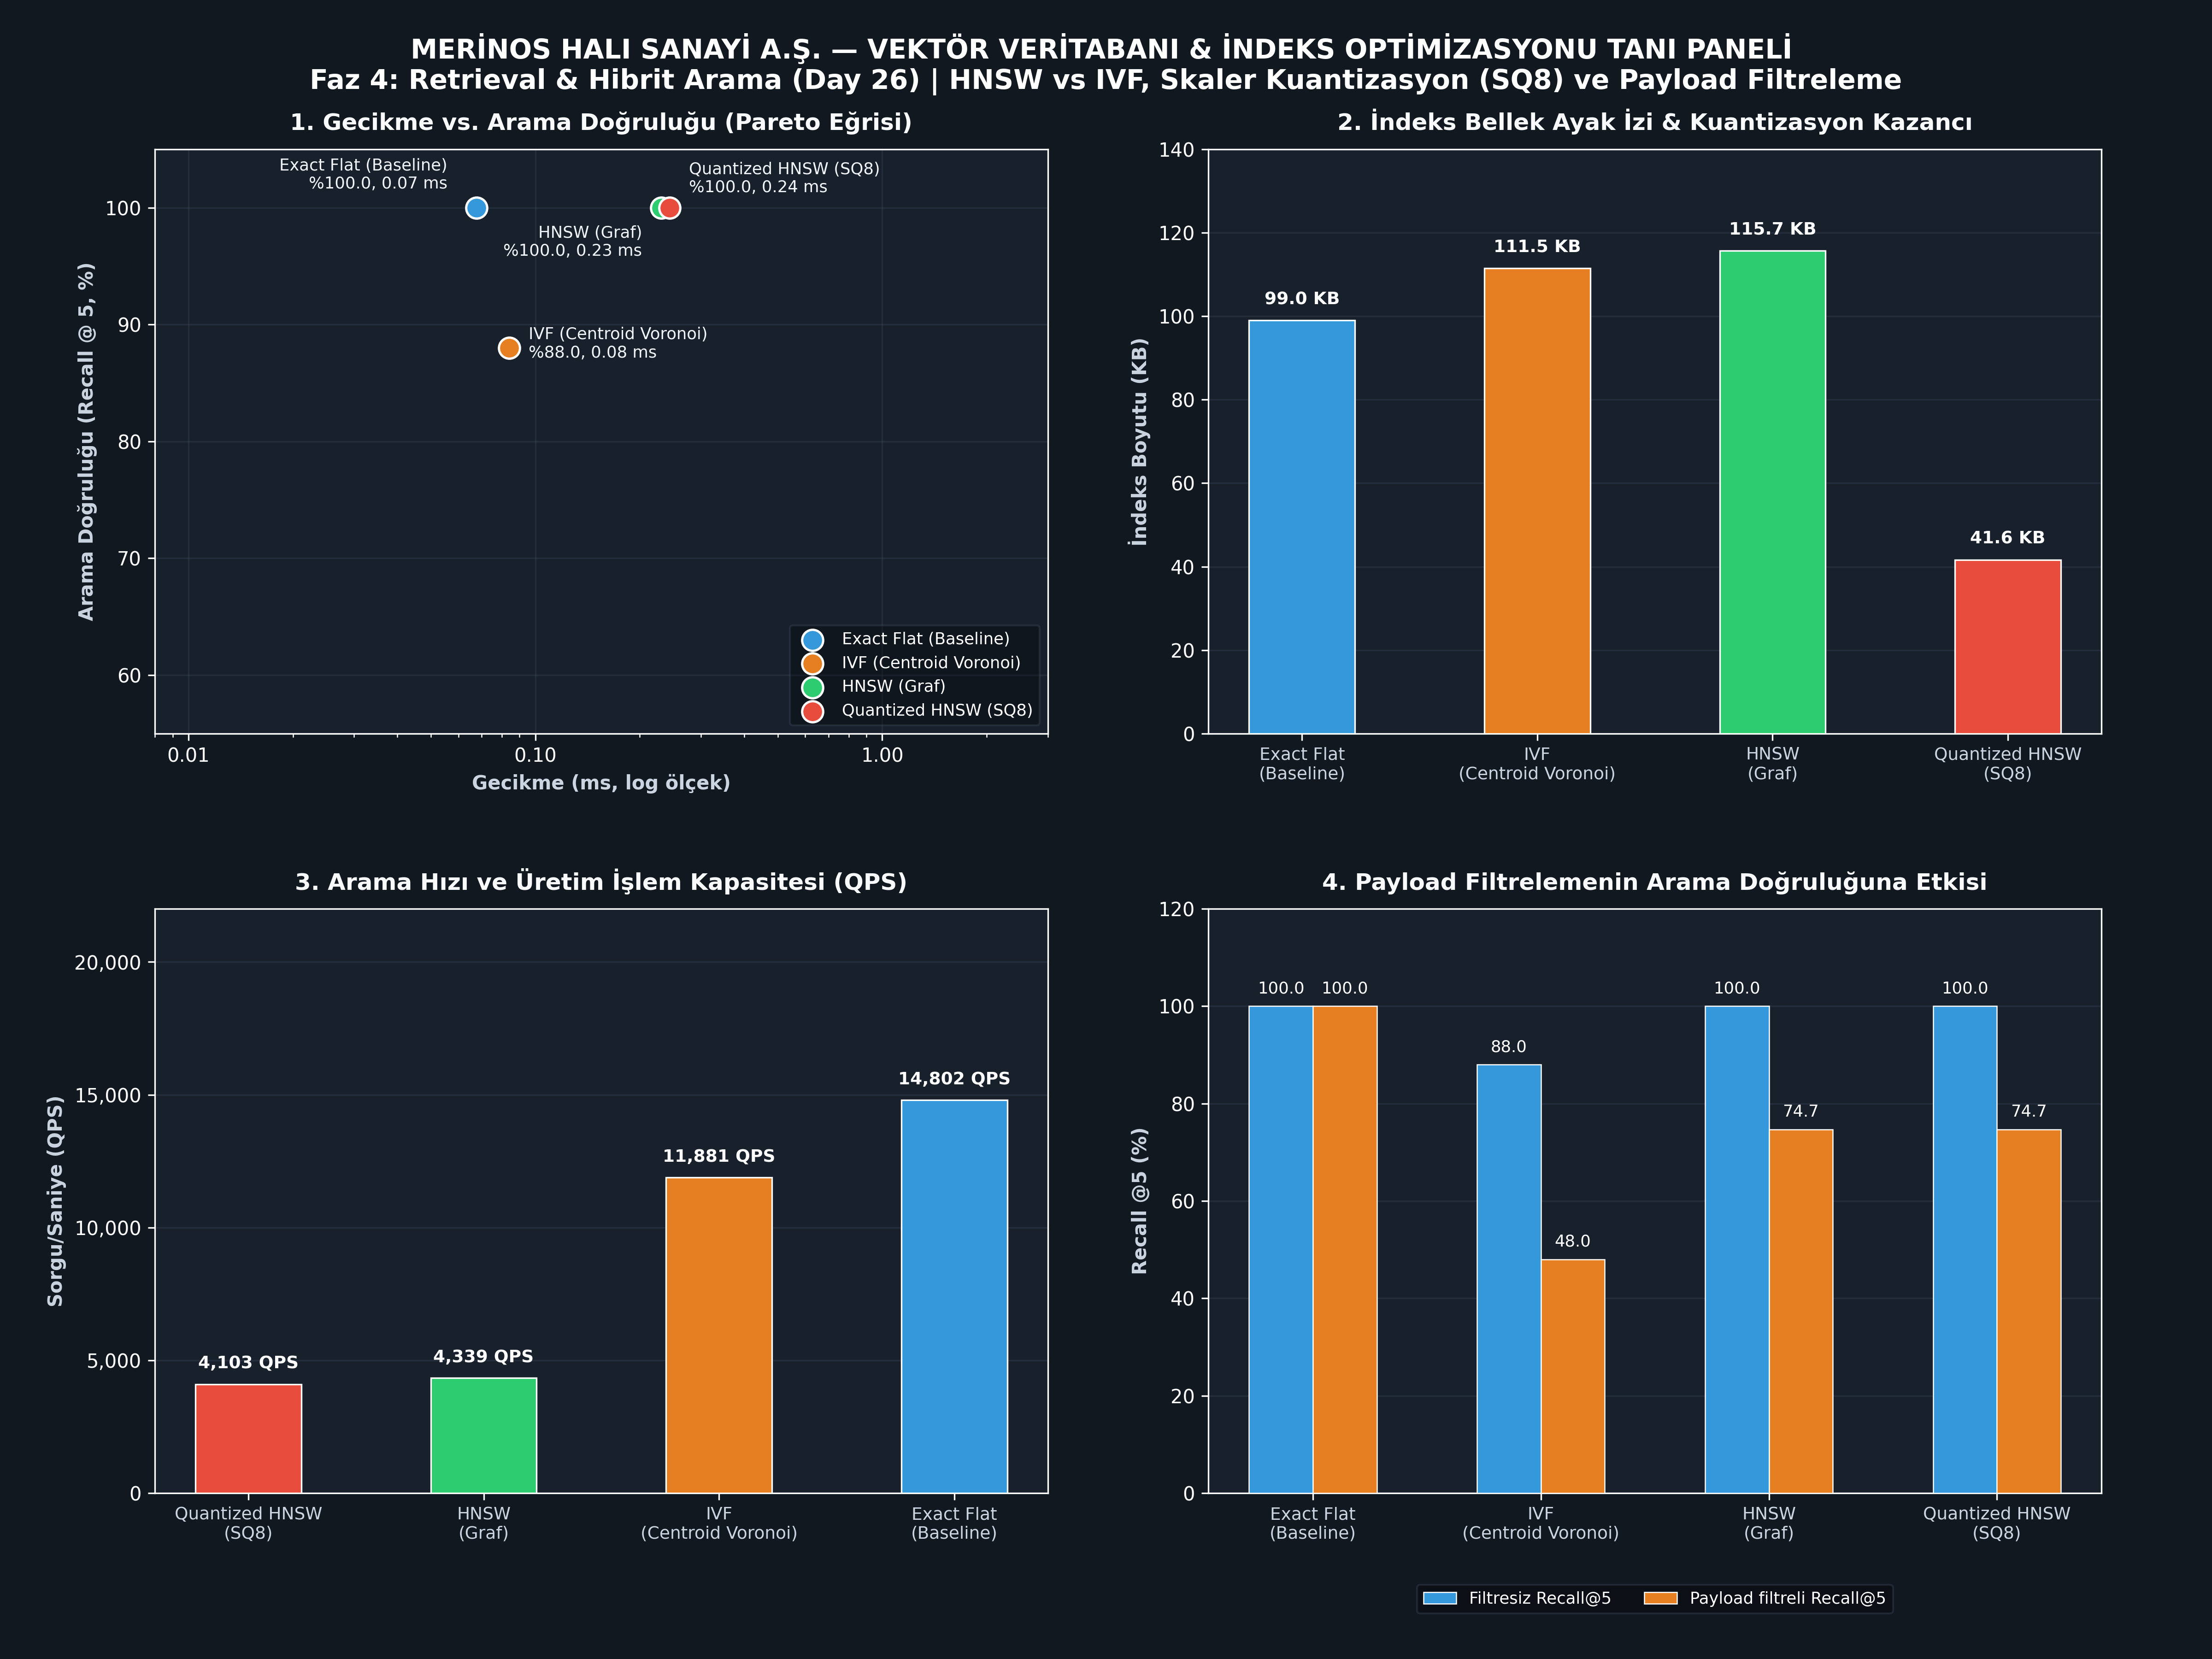

✅ 2x2 Tanı Paneli başarıyla görüntülendi ve kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day26\mini_project\outputs\vector_index_diagnostic_panel.png


In [10]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Dinamik ve izole proje kök dizini fallback çözümlemesi (hücre tekil çalıştırılsa dahi NameError önlenir)
if "repo_root" not in globals():
    CURRENT_DIR = Path.cwd().resolve()
    repo_root = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

output_panel_path = repo_root / "day26" / "mini_project" / "outputs" / "vector_index_diagnostic_panel.png"

# Eğer report nesnesi oturum belleğinde yoksa güvenli fallback ile oluştur
if "report" not in globals():
    import json
    from day26.mini_project.src.models import VectorPoint
    from day26.mini_project.src.benchmarker import VectorIndexBenchmarker
    from day26.mini_project.src.visualizer import plot_vector_index_diagnostic_panel
    
    corpus_p = repo_root / "day26" / "mini_project" / "fixtures" / "merinos_vector_corpus.json"
    queries_p = repo_root / "day26" / "mini_project" / "fixtures" / "filtered_benchmark_queries.json"
    
    with open(corpus_p, "r", encoding="utf-8") as f:
        c_points = [VectorPoint(**p) for p in json.load(f)]
    with open(queries_p, "r", encoding="utf-8") as f:
        q_raw = json.load(f)
        
    benchmarker = VectorIndexBenchmarker(c_points, q_raw)
    report = benchmarker.run_full_benchmark(top_k=5)

# 2x2 Master Tanı Panelini oluştur ve kaydet
panel_file = plot_vector_index_diagnostic_panel(report, str(output_panel_path))

# Şekil 52: 2x2 Tanı Panelini notebook hücresinde yüksek çözünürlüklü görsel olarak sergile
display(Image(filename=str(output_panel_path)))
print(f"✅ 2x2 Tanı Paneli başarıyla görüntülendi ve kaydedildi: {output_panel_path}")
